# Monte Carlo Stock Price Simulation

## Introduction

This project implements a Monte Carlo simulation framework to model stock price movements using the Wiener process (geometric Brownian motion). The simulation analyzes five major tech stocks (AAPL, GOOGL, NVDA, AMZN, UBER) over a 4+ year period, generating probabilistic price paths to understand potential 1 year future outcomes and risk profiles.

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
tickers = ["AAPL", "GOOG", "NVDA", "AMZN", "UBER"]
start_date = '2021-01-01'
end_date = '2025-09-25'
T = 1.0
dt = 1 / 252
all_simulations = {}

## Key Technical Implementation

**Wiener Process Model**: The core uses the stochastic differential equation:

$dS_t = μS_t\cdot dt + σS_t\cdot dW_t$

Where:
- $S_t$ = current stock price at time t
- $dS_t$ = infinitesimal change in stock price
- $μ$ (mu) = drift rate (annualized expected return), estimated from historical log returns
- $σ$ (sigma) = volatility (annualized standard deviation of returns), estimated from historical log returns
- $dt$ = infinitesimal time increment
- $dW_t$ = random increment from a Wiener process (standard normal distribution with mean 0 and variance dt)

**Risk Assessment**: The code evolves from single-path visualization to 100 000-simulation ensembles with confidence bands (5th-95th percentiles), providing a realistic range of potential outcomes.

### Functions

In [3]:
def get_stock_data(ticker, start_date, end_date):
    stock = yf.download(ticker, start=start_date, end=end_date, auto_adjust=False)
    return stock['Adj Close']

In [4]:
def wiener_process(S0, mu, sigma, T, dt):
    N = int(T / dt)
    t = np.linspace(0, T, N)
    W = np.random.standard_normal(size=N)
    W = np.cumsum(W) * np.sqrt(dt)
    X = (mu - 0.5 * sigma**2) * t + sigma * W
    S = S0 * np.exp(X)
    return t, S

### Single Simulation

In [5]:
# Basic simulation loop

for ticker in tickers:

    # Setup:
    stock_data = get_stock_data(ticker, start_date, end_date)
    log_returns = np.log(stock_data / stock_data.shift(1)).dropna()

    mu = (log_returns.mean() * 252).item()
    sigma = (log_returns.std() * np.sqrt(252)).item()

    S0 = stock_data.iloc[-1].item()

    # Run simulation
    t, S = wiener_process(S0, mu, sigma, T, dt)

    # Store data
    all_simulations[ticker] = S
    all_time = t

    # DataFrame creation and printing
    simulated_df = pd.DataFrame({
        'Time': t,
        'Simulated Price': S,
        'Initial Price (S0)': S0,
        'Drift (mu)': mu,
        'Volatility (sigma)': sigma
    })

    exec(f"simulated_{ticker} = simulated_df")

    print(f"Created DataFrame for {ticker}:")
    print(simulated_df.head())

[*********************100%***********************]  1 of 1 completed


Created DataFrame for AAPL:
       Time  Simulated Price  Initial Price (S0)  Drift (mu)  \
0  0.000000       256.536779          252.309998    0.147378   
1  0.003984       254.029458          252.309998    0.147378   
2  0.007968       251.360560          252.309998    0.147378   
3  0.011952       259.048848          252.309998    0.147378   
4  0.015936       255.291765          252.309998    0.147378   

   Volatility (sigma)  
0            0.282544  
1            0.282544  
2            0.282544  
3            0.282544  
4            0.282544  


[*********************100%***********************]  1 of 1 completed


Created DataFrame for GOOG:
       Time  Simulated Price  Initial Price (S0)  Drift (mu)  \
0  0.000000       249.997324          247.830002     0.22532   
1  0.003984       244.067908          247.830002     0.22532   
2  0.007968       243.251710          247.830002     0.22532   
3  0.011952       240.509995          247.830002     0.22532   
4  0.015936       232.710012          247.830002     0.22532   

   Volatility (sigma)  
0            0.310874  
1            0.310874  
2            0.310874  
3            0.310874  
4            0.310874  


[*********************100%***********************]  1 of 1 completed


Created DataFrame for NVDA:
       Time  Simulated Price  Initial Price (S0)  Drift (mu)  \
0  0.000000       178.498191          176.970001    0.553527   
1  0.003984       173.670475          176.970001    0.553527   
2  0.007968       186.159371          176.970001    0.553527   
3  0.011952       181.509667          176.970001    0.553527   
4  0.015936       186.685871          176.970001    0.553527   

   Volatility (sigma)  
0            0.525953  
1            0.525953  
2            0.525953  
3            0.525953  
4            0.525953  


[*********************100%***********************]  1 of 1 completed


Created DataFrame for AMZN:
       Time  Simulated Price  Initial Price (S0)  Drift (mu)  \
0  0.000000       216.870868          220.210007    0.068757   
1  0.003984       217.288921          220.210007    0.068757   
2  0.007968       218.024736          220.210007    0.068757   
3  0.011952       226.086352          220.210007    0.068757   
4  0.015936       228.414646          220.210007    0.068757   

   Volatility (sigma)  
0            0.352942  
1            0.352942  
2            0.352942  
3            0.352942  
4            0.352942  


[*********************100%***********************]  1 of 1 completed

Created DataFrame for UBER:
       Time  Simulated Price  Initial Price (S0)  Drift (mu)  \
0  0.000000       101.879652           97.779999    0.137719   
1  0.003984       101.158646           97.779999    0.137719   
2  0.007968       100.615497           97.779999    0.137719   
3  0.011952       103.290341           97.779999    0.137719   
4  0.015936       101.312695           97.779999    0.137719   

   Volatility (sigma)  
0            0.466166  
1            0.466166  
2            0.466166  
3            0.466166  
4            0.466166  


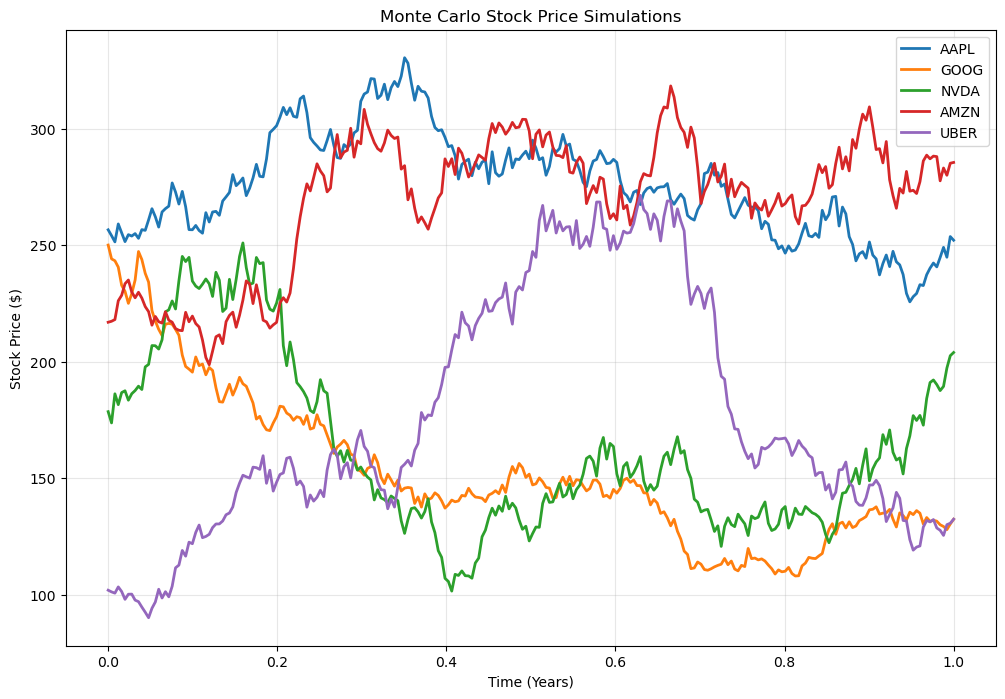

In [6]:
# Single Simulation Viz

plt.figure(figsize=(12, 8))
for ticker in tickers:
    plt.plot(all_time, all_simulations[ticker], label=ticker, linewidth=2)

plt.xlabel('Time (Years)')
plt.ylabel('Stock Price ($)')
plt.title('Monte Carlo Stock Price Simulations')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Multiple Simulations

In [7]:
# 100 000-simulation loop

num_simulations = 100000
all_paths = {ticker: [] for ticker in tickers}

for ticker in tickers:
    stock_data = get_stock_data(ticker, start_date, end_date)
    log_returns = np.log(stock_data / stock_data.shift(1)).dropna()
    
    mu = (log_returns.mean() * 252).item()
    sigma = (log_returns.std() * np.sqrt(252)).item()
    S0 = stock_data.iloc[-1].item()
    
    for _ in range(num_simulations):
        t, S = wiener_process(S0, mu, sigma, T, dt)
        all_paths[ticker].append(S)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [8]:
# Confidence band calculations

confidence_data = {}

for ticker in tickers:
    paths_array = np.array(all_paths[ticker])
    
    # Calculate percentiles for confidence bands
    p50 = np.percentile(paths_array, 50, axis=0)
    p05 = np.percentile(paths_array, 5, axis=0)
    p95 = np.percentile(paths_array, 95, axis=0)

    # Store all calculations
    confidence_data[ticker] = {
        'median': p50,
        'p05': p05,
        'p95': p95,
        'paths_array': paths_array
    }

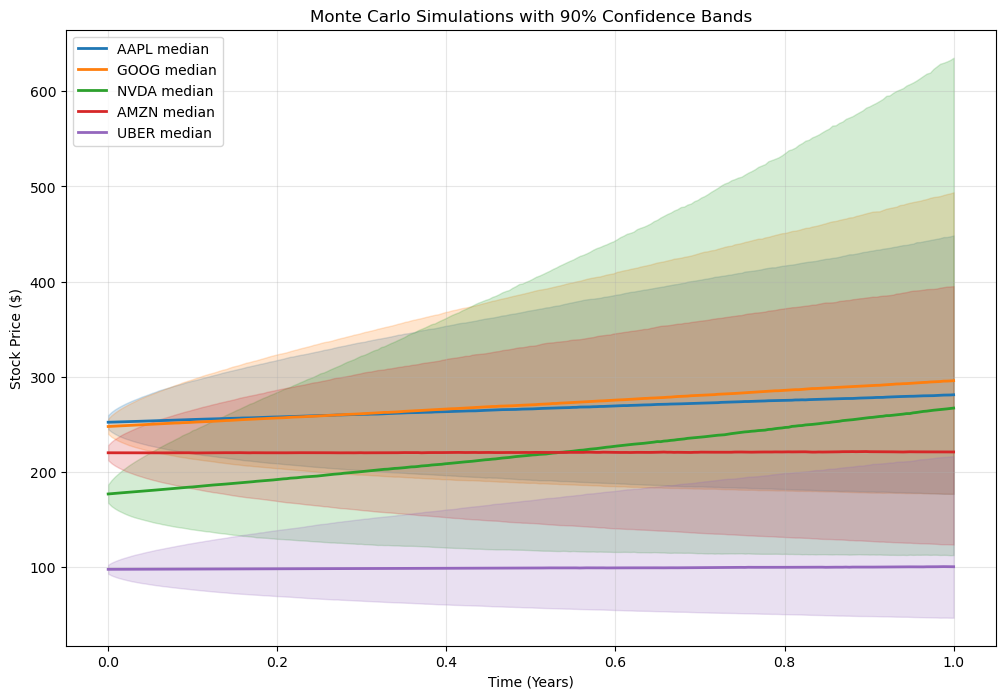

In [9]:
# Combained plot

plt.figure(figsize=(12, 8))
colors = {} 

for i, ticker in enumerate(tickers):
    data = confidence_data[ticker]
    line, = plt.plot(t, data['median'], label=f'{ticker} median', linewidth=2)
    colors[ticker] = line.get_color()  # Save the color for the next plot
    plt.fill_between(t, data['p05'], data['p95'], alpha=0.2, color=colors[ticker])
    
plt.xlabel('Time (Years)')
plt.ylabel('Stock Price ($)')
plt.title('Monte Carlo Simulations with 90% Confidence Bands')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

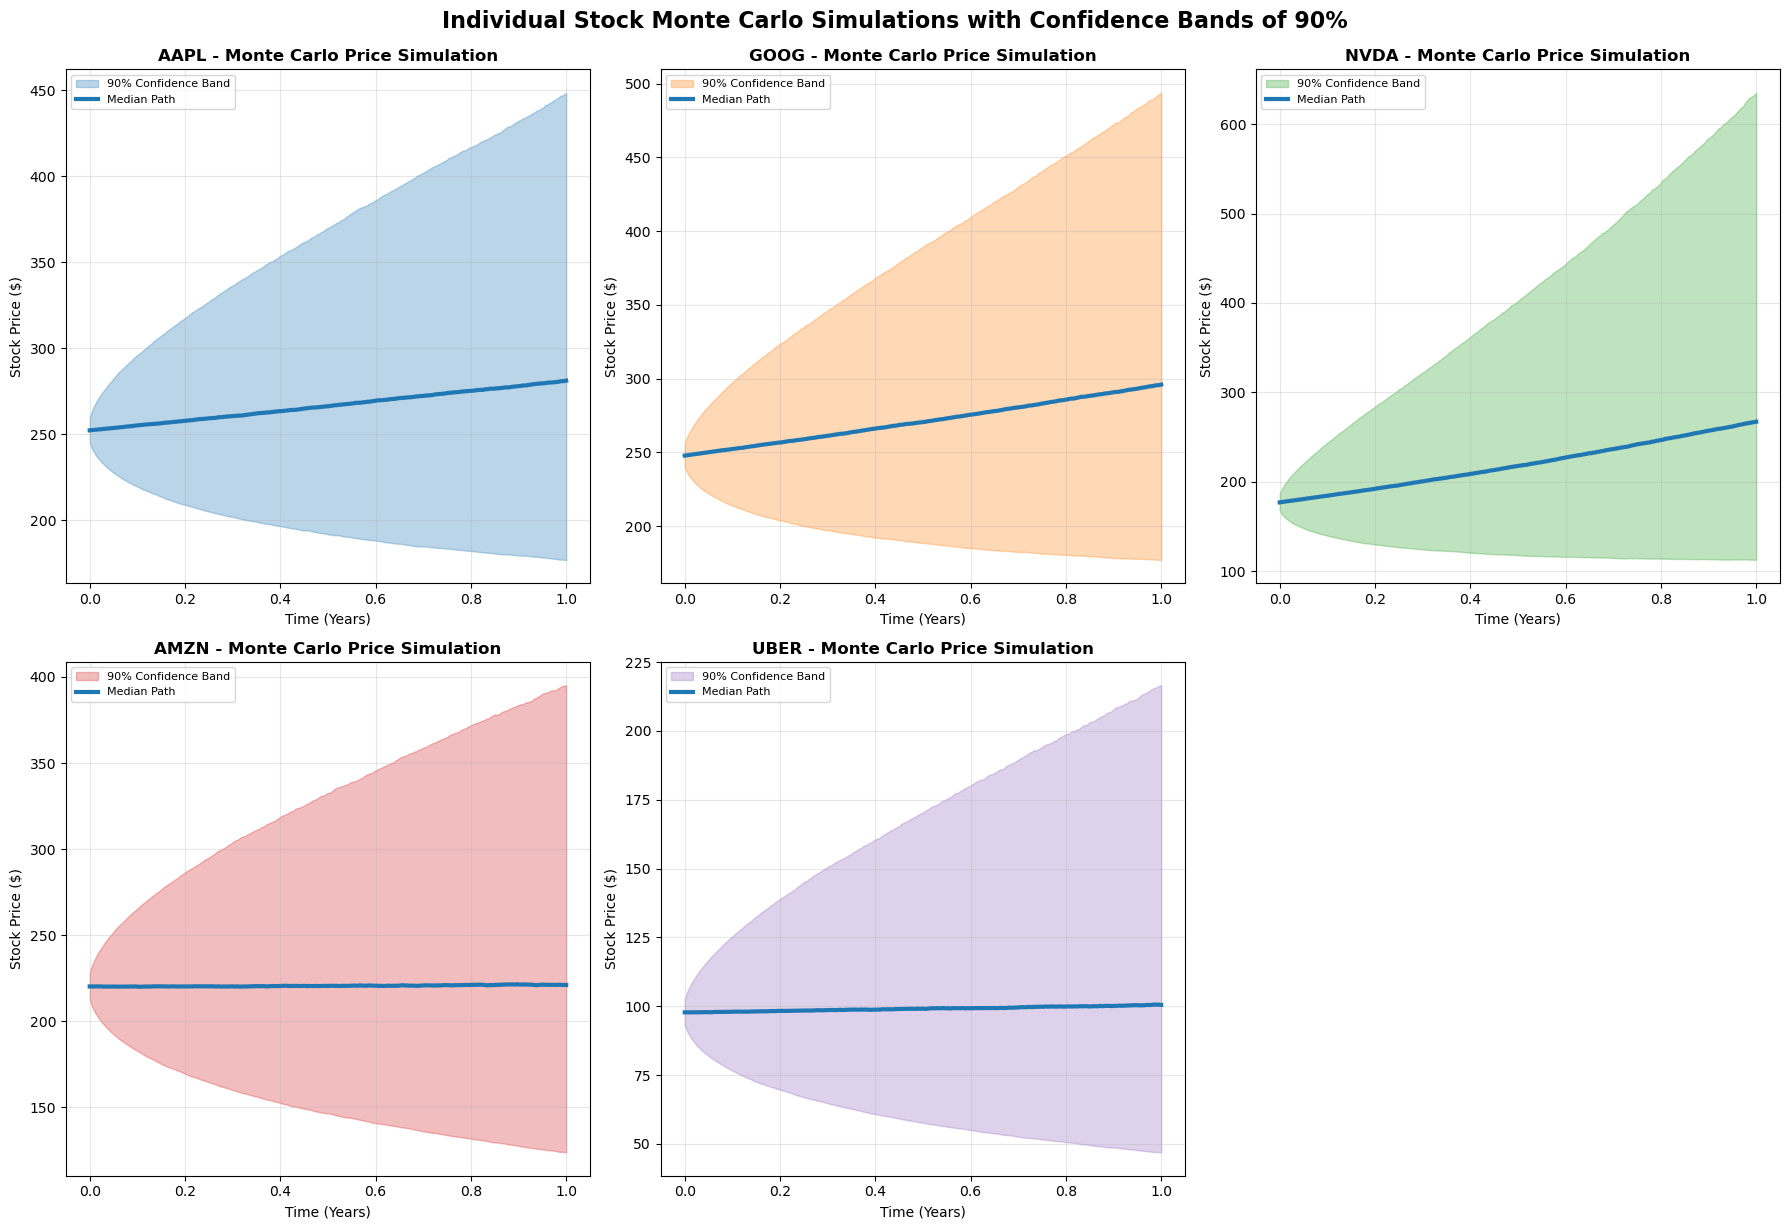

In [10]:
# Individual subplots for detailed analysis

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    ax = axes[i]
    data = confidence_data[ticker]
    
    ax.fill_between(t, data['p05'], data['p95'], alpha=0.3, color=colors[ticker], label='90% Confidence Band')
    ax.plot(t, data['median'], linewidth=3, label='Median Path')
    
    ax.set_title(f'{ticker} - Monte Carlo Price Simulation', fontsize=12, fontweight='bold')
    ax.set_xlabel('Time (Years)')
    ax.set_ylabel('Stock Price ($)')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

axes[5].remove()

plt.tight_layout()
plt.suptitle('Individual Stock Monte Carlo Simulations with Confidence Bands of 90%', 
             fontsize=16, fontweight='bold', y=1.02)
plt.show()

In [11]:
# Print summary statistics

for ticker in tickers:
    data = confidence_data[ticker]
    initial_price = data['paths_array'][0, 0]  # Starting price
    final_median = data['median'][-1]
    final_p05 = data['p05'][-1]
    final_p95 = data['p95'][-1]
    
    print(f"\n{ticker}:")
    print(f"  Initial Price: ${initial_price:.2f}")
    print(f"  Final Median:  ${final_median:.2f} ({((final_median/initial_price-1)*100):+.1f}%)")
    print(f"  90% Confidence Interval: ${final_p05:.2f} to ${final_p95:.2f}")
    print(f"  Risk Spread:   ${final_p95-final_p05:.2f} ({((final_p95-final_p05)/final_median*100):.1f}% of median)")


AAPL:
  Initial Price: $261.08
  Final Median:  $281.15 (+7.7%)
  90% Confidence Interval: $177.02 to $448.48
  Risk Spread:   $271.46 (96.6% of median)

GOOG:
  Initial Price: $259.38
  Final Median:  $295.96 (+14.1%)
  90% Confidence Interval: $177.16 to $493.83
  Risk Spread:   $316.66 (107.0% of median)

NVDA:
  Initial Price: $184.17
  Final Median:  $267.17 (+45.1%)
  90% Confidence Interval: $112.77 to $635.19
  Risk Spread:   $522.41 (195.5% of median)

AMZN:
  Initial Price: $225.17
  Final Median:  $221.06 (-1.8%)
  90% Confidence Interval: $123.84 to $395.23
  Risk Spread:   $271.39 (122.8% of median)

UBER:
  Initial Price: $97.93
  Final Median:  $100.51 (+2.6%)
  90% Confidence Interval: $46.95 to $216.60
  Risk Spread:   $169.65 (168.8% of median)


## Key Insights

**Risk–Return Profile Comparison:** 

- NVIDIA (NVDA) stands out as the most volatile stock, with a 52.6% annualized volatility and a risk spread nearly 190% of its median outcome. This makes NVDA highly unpredictable - capable of delivering exceptional returns, but also steep losses.
- Apple (AAPL) and Google (GOOG) demonstrate moderate volatility (around 28–31%) and tighter confidence intervals, signaling more stable price behavior. Both exhibit median returns above market benchmarks (S&P 500 ≈ 10.5% annual growth), with AAPL at ~12% and GOOG at ~18%, suggesting they offer a strong balance of growth and stability.
- Amazon (AMZN) occupies a challenging middle ground - showing moderate risk (~123% spread) but a low median return of just 1.8%. This results in a poor risk–reward tradeoff, where the volatility isn’t adequately compensated by expected performance.
- Uber (UBER) displays elevated downside volatility (~170% spread) and a modest median return (+7.4%), meaning investors face substantial risk without sufficient upside relative to the market.

**Downside Risk Assessment (5% Worst-Case Outcomes):** The 5th percentile outcomes - representing the worst 5% of simulated scenarios - quantify potential downside exposure:

| Stock    | 5th Percentile         | Interpretation                                                      |
| -------- | ---------------------- | ------------------------------------------------------------------- |
| **UBER** | –50.3%                 | Highest downside risk; substantial vulnerability in adverse markets |
| **AMZN** | –43.0%                 | Significant downside, magnified by weak median return               |
| **NVDA** | –37.6%                 | Volatile but better compensated by higher upside potential          |
| **AAPL** | –29.9%                 | Moderate downside; relatively stable performance under stress       |
| **GOOG** | –29.0%                 | Most resilient; strongest downside protection among peers           |


## Practical Applications

**Portfolio Risk Management**: The risk spread metric allows you to scale position sizes inversely to volatility. By weighting positions based on their confidence intervals relative to your portfolio's target volatility, you can construct diversified exposure where no single position dominates total portfolio risk.

**Options Strategy Selection**: The wide confidence intervals for NVDA and AMZN suggest profitable opportunities for volatility-based strategies (selling strangles, iron condors). Conversely, the tighter bands for AAPL and GOOG indicate lower option premiums but more predictable outcomes.

**Stop-Loss Calibration**: Use the 5th percentile values to set informed stop-losses. Setting stops tighter than these levels means you'll likely be stopped out even in normal market conditions. The p05 values represent statistically-driven floor levels for each position.


## Conclusion

This Monte Carlo framework provides a solid foundation for understanding stock price uncertainty and risk through geometric Brownian motion. The model assumes **constant drift and volatility parameters** throughout the simulation period - meaning each stock's growth rate and risk level remain fixed based on historical averages.

**Production Extensions**: For more sophisticated analysis, it is recomended to consider:
- **Stochastic volatility models** (like Heston) where volatility itself fluctuates randomly
- **Regime-switching dynamics** that account for different market conditions (bull vs bear markets with distinct risk-return profiles)
- **Jump-diffusion processes** to capture sudden price movements from earnings or news events

While these extensions add mathematical complexity, the current model's probabilistic approach already provides valuable insights for portfolio risk management, scenario planning, and understanding the range of potential investment outcomes.